# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hcfc22"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[96.22 96.24400000000001 96.268 ... 109.75333333333333 111.44 111.53] [96.22 96.244 96.268 ... 111.63666666666667 111.58333333333334 111.53] [96.22 96.24400000000001 97.35928571428572 ... 108.91830188679246 110.35924528301886 111.53] [96.22 97.66094339622641 99.10188679245283 ... 109.18849056603773 110.62943396226416 111.53] [96.22 96.244 97.93333333333334 ... 109.45867924528301 110.89962264150944 111.53] [96.22 96.244 96.268 ... 109.72886792452829 111.16981132075472 111.53]] [[96.42 96.39444444444445 96.36888888888888 ... 109.05000000000001 110.555 112.06] [96.42 96.39444444444443 96.7121212121212 ... 111.89999999999999 111.98 112.06] [96.42 96.5660606060606 98.02285714285715 ... 108.13083333333333 110.40180555555555 112.06] [96.42 97.8130303030303 99.20606060606059 ... 108.74361111111112 110.555 112.06] [96.42 96.39444444444445 97.07818181818182 ... 109.05 110.555 112.06] [96.42 96.39444444444445 96.36888888888888 ... 109.05000000000001 110.555 112.06]] [[95.60666666666668 95.33944444444447 95.07222222222224 ... 109.738 112.66 112.66] [95.60666666666668 95.33944444444445 95.75939393939395 ... 110.1092857142857 112.66 112.66] [95.60666666666668 95.68303030303032 97.39511111111112 ... 110.1092857142857 112.66 112.66] [95.60666666666668 96.69982758620691 97.79298850574713 ... 110.1092857142857 112.66 112.66] [95.60666666666668 95.33944444444445 95.75241379310346 ... 110.1092857142857 112.66 112.66] [95.60666666666668 95.33944444444447 95.07222222222222 ... 110.1092857142857 112.65999999999998 112.66]] ... [[238.225 238.45333333333332 238.68166666666667 ... 254.42125 253.7725 253.4575] [238.225 238.45333333333332 238.57590909090908 ... 257.235 255.34625 253.4575] [238.225 238.40045454545455 239.63071428571428 ... 254.005 253.73583333333332 253.4575] [238.225 239.7604761904762 241.29595238095237 ... 253.39425925925926 253.74500000000003 253.4575] [238.225 238.45333333333332 239.33523809523808 ... 252.78351851851852 253.7541666666667 253.4575] [238.225 238.45333333333332 238.68166666666667 ... 252.17277777777778 253.76333333333335 253.4575]] [[238.07 238.28250000000003 238.49500000000003 ... 253.56375000000003 253.33 253.1225] [238.07 238.28250000000003 239.59003508771931 ... 260.26 256.69124999999997 253.1225] [238.07 238.83001754385964 241.23258771929824 ... 253.08 253.12666666666667 253.1225] [238.07 239.52988095238092 240.98976190476193 ... 252.60324074074077 253.1775 253.1225] [238.06999999999996 238.2825 239.11869047619047 ... 252.1264814814815 253.22833333333335 253.1225] [238.07 238.2825 238.49499999999998 ... 251.64972222222224 253.27916666666667 253.1225]] [[238.455 238.54416666666668 238.63333333333335 ... 253.41866666666664 253.064 253.15] [238.455 238.54416666666668 239.79004385964913 ... 253.04 253.095 253.15] [238.455 239.12252192982456 241.5251096491228 ... 253.2 253.16266666666664 253.15] [238.455 239.8720238095238 241.28904761904764 ... 252.6335740740741 253.138 253.15] [238.455 238.54416666666665 239.2972619047619 ... 252.06714814814816 253.11333333333332 253.15] [238.455 238.54416666666668 238.63333333333333 ... 251.50072222222218 253.08866666666665 253.15]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[96.22 96.24400000000001 96.268 ... 109.75333333333333 111.44 111.53] [96.22 96.244 96.268 ... 111.63666666666667 111.58333333333334 111.53] [96.22 96.24400000000001 97.35928571428572 ... 108.91830188679246 110.35924528301886 111.53] [96.22 97.66094339622641 99.10188679245283 ... 109.18849056603773 110.62943396226416 111.53] [96.22 96.244 97.93333333333334 ... 109.45867924528301 110.89962264150944 111.53] [96.22 96.244 96.268 ... 109.72886792452829 111.16981132075472 111.53]] [[96.42 96.39444444444445 96.36888888888888 ... 109.05000000000001 110.555 112.06] [96.42 96.39444444444443 96.7121212121212 ... 111.89999999999999 111.98 112.06] [96.42 96.5660606060606 98.02285714285715 ... 108.13083333333333 110.40180555555555 112.06] [96.42 97.8130303030303 99.20606060606059 ... 108.74361111111112 110.555 112.06] [96.42 96.39444444444445 97.07818181818182 ... 109.05 110.555 112.06] [96.42 96.39444444444445 96.36888888888888 ... 109.05000000000001 110.555 112.06]] [[95.60666666666668 95.33944444444447 95.07222222222224 ... 109.738 112.66 112.66] [95.60666666666668 95.33944444444445 95.75939393939395 ... 110.1092857142857 112.66 112.66] [95.60666666666668 95.68303030303032 97.39511111111112 ... 110.1092857142857 112.66 112.66] [95.60666666666668 96.69982758620691 97.79298850574713 ... 110.1092857142857 112.66 112.66] [95.60666666666668 95.33944444444445 95.75241379310346 ... 110.1092857142857 112.66 112.66] [95.60666666666668 95.33944444444447 95.07222222222222 ... 110.1092857142857 112.65999999999998 112.66]] ... [[238.225 238.45333333333332 238.68166666666667 ... 254.42125 253.7725 253.4575] [238.225 238.45333333333332 238.57590909090908 ... 257.235 255.34625 253.4575] [238.225 238.40045454545455 239.63071428571428 ... 254.005 253.73583333333332 253.4575] [238.225 239.7604761904762 241.29595238095237 ... 253.39425925925926 253.74500000000003 253.4575] [238.225 238.45333333333332 239.33523809523808 ... 252.78351851851852 253.7541666666667 253.4575] [238.225 238.45333333333332 238.68166666666667 ... 252.17277777777778 253.76333333333335 253.4575]] [[238.07 238.28250000000003 238.49500000000003 ... 253.56375000000003 253.33 253.1225] [238.07 238.28250000000003 239.59003508771931 ... 260.26 256.69124999999997 253.1225] [238.07 238.83001754385964 241.23258771929824 ... 253.08 253.12666666666667 253.1225] [238.07 239.52988095238092 240.98976190476193 ... 252.60324074074077 253.1775 253.1225] [238.06999999999996 238.2825 239.11869047619047 ... 252.1264814814815 253.22833333333335 253.1225] [238.07 238.2825 238.49499999999998 ... 251.64972222222224 253.27916666666667 253.1225]] [[238.455 238.54416666666668 238.63333333333335 ... 253.41866666666664 253.064 253.15] [238.455 238.54416666666668 239.79004385964913 ... 253.04 253.095 253.15] [238.455 239.12252192982456 241.5251096491228 ... 253.2 253.16266666666664 253.15] [238.455 239.8720238095238 241.28904761904764 ... 252.6335740740741 253.138 253.15] [238.455 238.54416666666665 239.2972619047619 ... 252.06714814814816 253.11333333333332 253.15] [238.455 238.54416666666668 238.63333333333333 ... 251.50072222222218 253.08866666666665 253.15]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hcfc22' (lon: 6, lat: 12, year: 26, month: 12)> Size: 180kB
<Quantity([[[[120.33       122.26       121.66       ... 126.
    125.67       125.02      ]
   [125.92       126.31       126.92       ... 129.105
    130.2        130.575     ]
   [130.225      130.355      132.26       ... 135.57
    135.82666667 135.87      ]
   ...
   [238.58       238.635      238.78333333 ... 241.65666667
    241.4        240.48333333]
   [239.9625     239.4975     239.78       ... 241.78
    241.22333333 240.7       ]
   [239.315      239.04       238.945      ... 240.45
    239.69333333 238.98      ]]

  [[120.33       121.63333333 122.52885    ... 125.69656667
    126.3363     125.76275   ]
   [125.2381     125.48666667 126.28965    ... 130.62566667
    130.81845    130.69485   ]
   [130.50065    130.52163333 131.33735    ... 135.3748
    135.99618333 135.935025  ]
...
   [259.16841667 259.26283333 259.5905     ... 258.6915
    259.799      260.61733333]
   [260.63875    259.93141667 259.63941667 ... 257.60027778
    258.30941667 258.64916667]
   [258.2605     258.18905556 258.15511111 ... 255.14311111
    256.11608333 257.35466667]]

  [[140.535      140.57       140.06       ... 143.05
    144.43       146.37      ]
   [148.26       145.855      146.77333333 ... 147.7
    150.3        151.17      ]
   [150.88       151.52333333 150.90666667 ... 154.175
    155.0425     156.36      ]
   ...
   [259.16333333 259.13175    259.0275     ... 259.32825
    260.185      261.0805    ]
   [260.73475    259.95575    259.8145     ... 257.90325
    258.568      259.0125    ]
   [258.534      258.323      258.44416667 ... 254.59016667
    255.899      257.0405    ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 208B 1998 1999 2000 2001 2002 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[120.33 122.26 121.66 ... 240.45 239.69333333333336 238.98] [120.33 121.63333333333334 122.52884999999999 ... 240.639875 239.70921666666666 239.31085] [120.6425 121.37666666666667 122.35925 ... 240.664375 239.94774999999998 239.31425] ... [137.60944444444445 138.86166666666668 137.53027777777777 ... 256.1485 256.5415833333333 257.32125] [139.9675 140.57000000000002 139.09333333333333 ... 255.41400000000004 256.2 257.6825] [140.53500000000005 140.57000000000002 140.06 ... 254.91175 256.0325 257.09025]] [[120.33 122.26 121.66 ... 240.45 239.69333333333336 238.98] [120.33 121.51 122.87499999999999 ... 240.695 239.635 239.41999999999996] [130.16785714285714 123.86023809523809 124.84642857142858 ... 243.66625 242.25642857142856 242.20119047619045] ... [139.97 141.49 137.80333333333334 ... 257.745 258.755 258.265] [140.25250000000003 140.57000000000002 138.93166666666667 ... 256.4891666666667 257.4605 257.7025] [140.53500000000005 140.57000000000002 140.06 ... 255.23333333333335 256.166 257.14]] [[120.33 122.25999999999999 121.65999999999998 ... 240.45 239.69333333333333 238.98] [120.33 123.06011904761905 123.2532142857143 ... 241.4654705882353 240.62892156862745 240.31154545454544] [125.40517857142856 125.41035714285715 125.22464285714285 ... 243.25141176470586 242.558431372549 242.53463636363637] ... [135.64000000000004 140.73215686274511 135.505875 ... 255.753 256.065 257.955] [138.2963888888889 140.57000000000002 137.92853703703705 ... 256.095 256.47 257.44] [140.53500000000005 140.57000000000002 140.06 ... 254.59016666666668 255.899 257.04049999999995]] [[120.33 122.26 121.66 ... 240.45 239.69333333333336 238.98] [120.33 123.77777777777777 123.04168181818181 ... 242.30887499999997 241.8084791666667 241.1078125] [120.6425 125.29555555555555 124.42336363636363 ... 244.16774999999998 243.92362500000002 243.23562499999997] ... [136.0577777777778 139.9743137254902 135.7970740740741 ... 255.25566666666668 256.2645 256.457] [138.7141666666667 140.57000000000002 138.2197361111111 ... 254.60133333333334 255.94825 256.69899999999996] [140.53500000000005 140.57000000000002 140.06 ... 253.947 255.632 256.941]] [[120.33 122.25999999999999 121.65999999999998 ... 240.45 239.69333333333333 238.98] [120.33 121.88000000000001 121.83655 ... 240.52962499999998 239.85765 239.09255] [120.6425 122.51055555555556 122.44259090909091 ... 241.47131249999998 241.03448958333334 240.15815625] ... [136.4755555555556 139.2164705882353 136.08827314814818 ... 255.55327777777777 256.3568611111111 256.7450833333333] [139.13194444444446 140.57000000000002 138.5109351851852 ... 254.87222222222226 256.0321666666667 257.02683333333334] [140.53500000000005 140.57000000000002 140.06 ... 254.26858333333334 255.7655 256.99075]] [[120.33 122.26 121.66 ... 240.45 239.69333333333336 238.98] [120.33 121.75666666666667 122.1827 ... 240.58474999999999 239.78343333333333 239.2017] [120.6425 121.50000000000001 122.01310000000001 ... 240.60924999999997 240.02196666666666 239.2051] ... [136.89333333333335 138.4586274509804 136.37947222222223 ... 255.8508888888889 256.4492222222222 257.03316666666666] [139.54972222222224 140.57000000000002 138.80213425925928 ... 255.14311111111115 256.11608333333334 257.3546666666667] [140.53500000000005 140.57000000000002 140.06 ... 254.59016666666668 255.899 257.04049999999995]]]
Units,ppt


### Longitudinal-mean

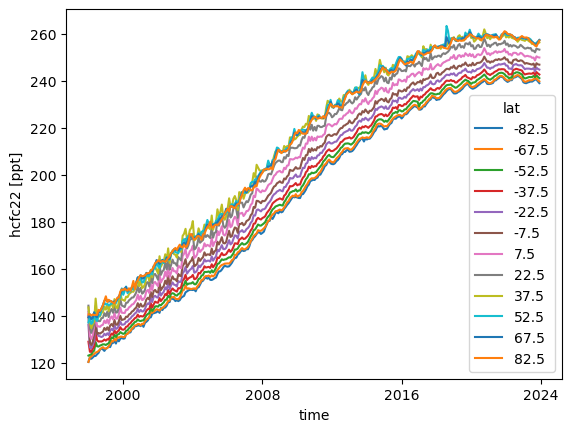

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

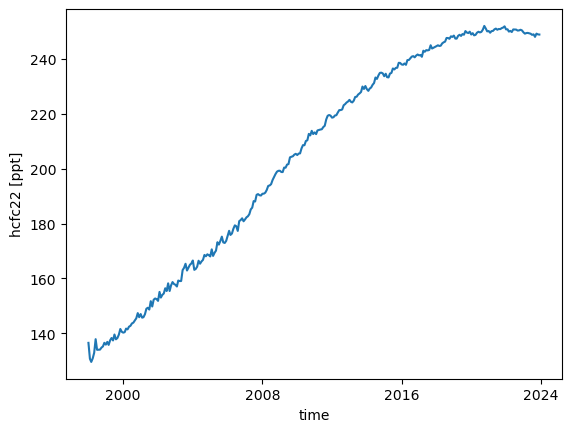

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

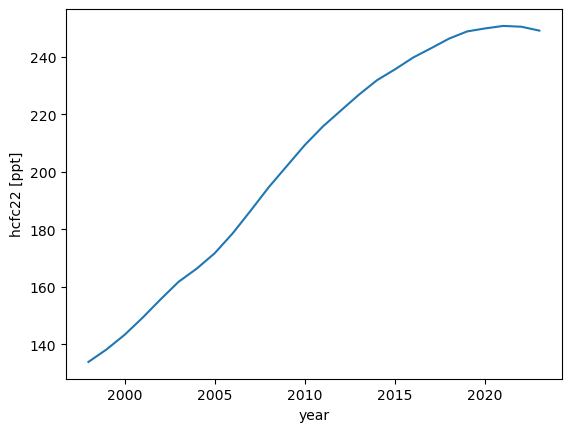

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 26)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 208B 1998 1999 2000 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4283 ... -0.05329
    principal-components  (year, eof) float64 2kB [] -22.66 ... 1.158e-14

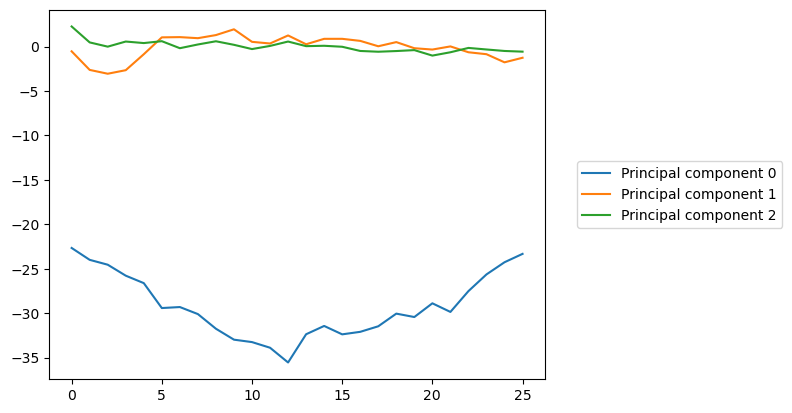

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

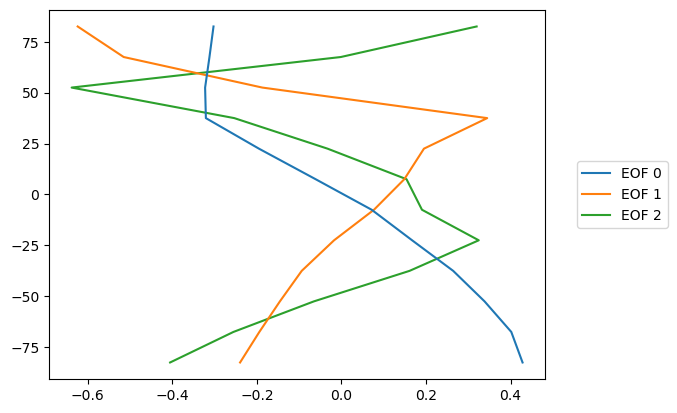

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

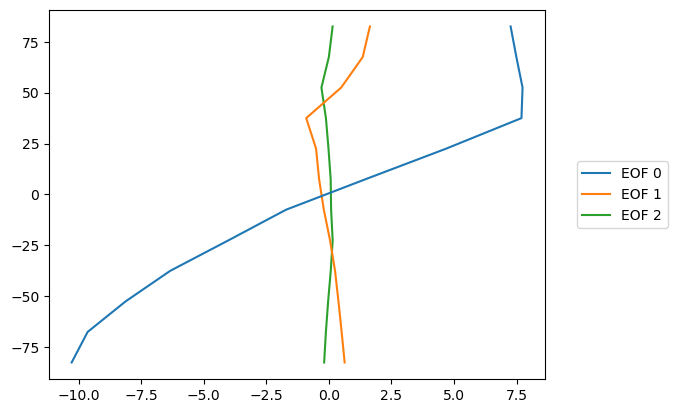

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.4283481783676052] [0.4017105602812429] [0.33850690097066216] [0.2642274538660623] [0.16713743450049107] [0.07144744177564712] [-0.061099687144553154] [-0.19516218651550424] [-0.32067217329851067] [-0.32249464358822366] [-0.3121982009587227] [-0.30262374353488364]]
Units,ppt
Magnitude,[[-22.659497266556535] [-23.995347995772068] [-24.54245816267994] [-25.77676535871999] [-26.6158553524962] [-29.41904394203647] [-29.306478678973235] [-30.09800591671308] [-31.74646443240511] [-32.976888095958934] [-33.24876019977506] [-33.8836998085825] [-35.54246848070861] [-32.36675010175976] [-31.43262002553688] [-32.37769210890071] [-32.09478296392121] [-31.47096468032083] [-30.04661063530113] [-30.429376166987893] [-28.88536234268147] [-29.856437772795466] [-27.51341358129064] [-25.634787289440695] [-24.266023049612446] [-23.323610851741226]]
Units,dimensionless


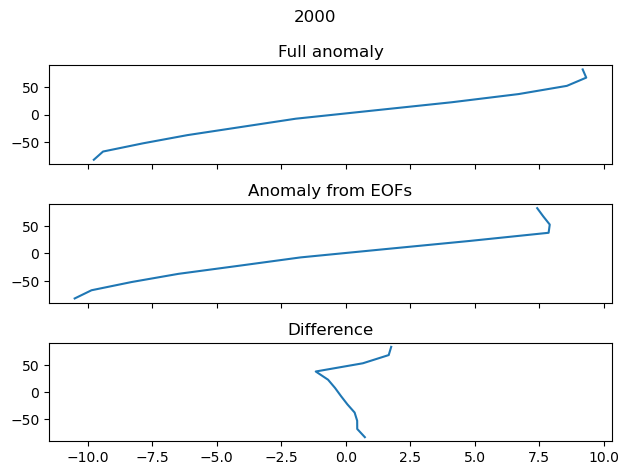

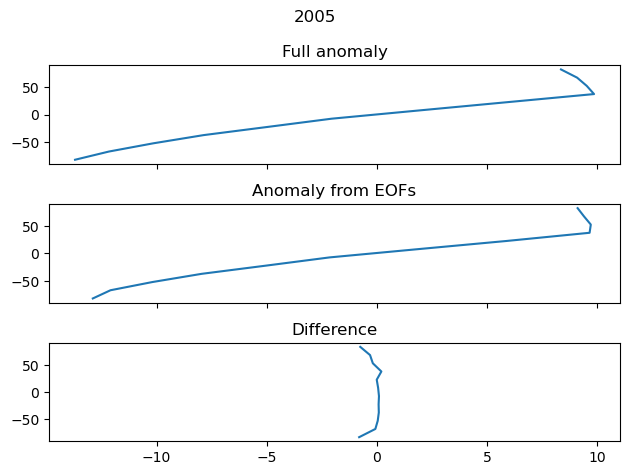

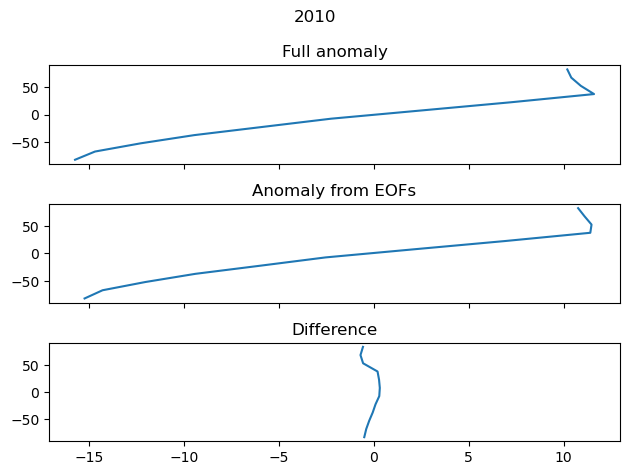

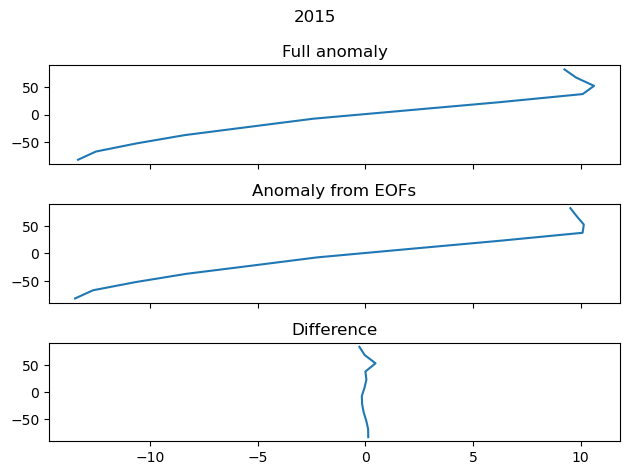

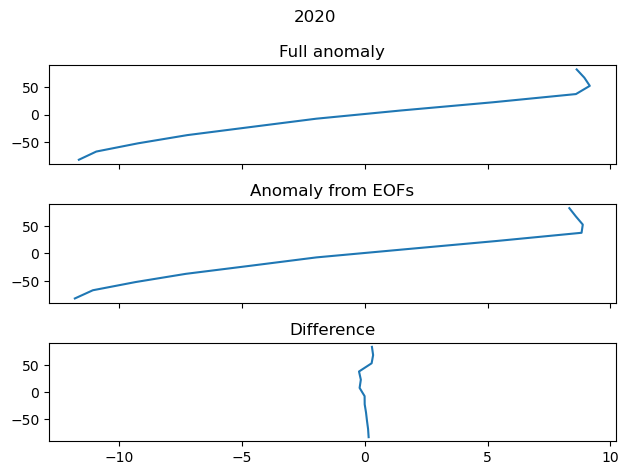

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 12114.97it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 19521.78it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/312 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 19721.84it/s]

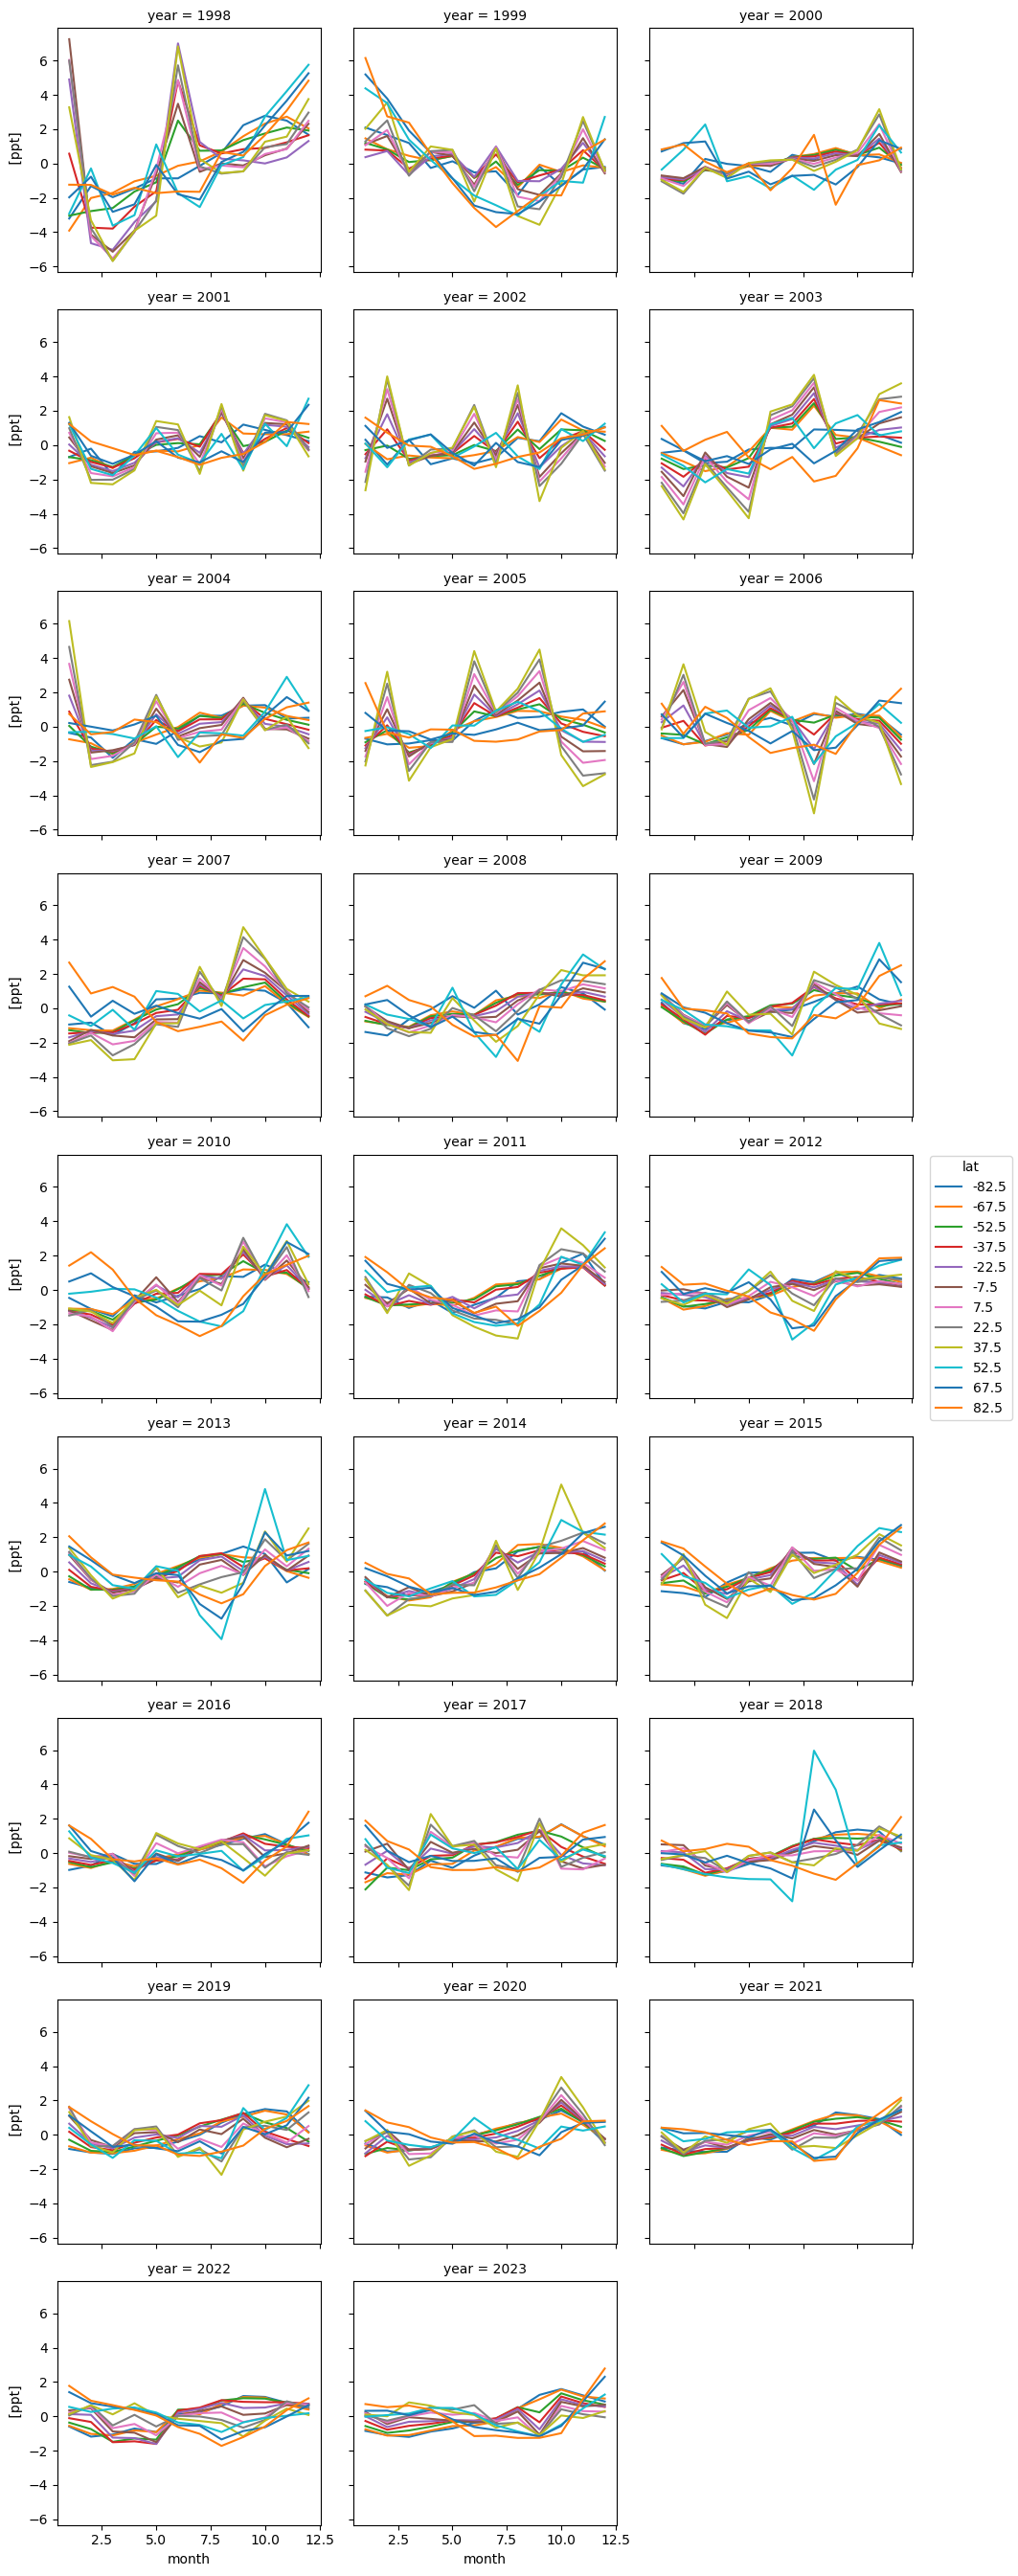

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

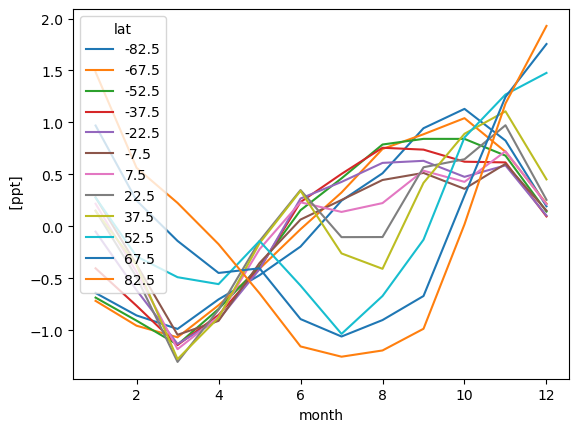

In [22]:
seasonality.plot.line(hue="lat")

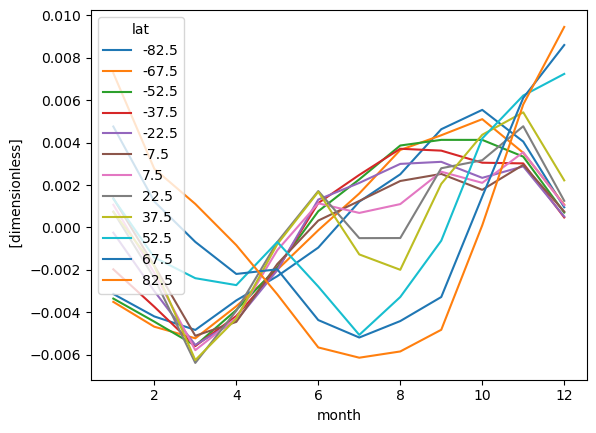

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[133.92441853901911 138.25199668747578 143.3261722630231 149.28231161968282 155.67329116953837 161.79785098522603 166.34035825351017 171.71171459326308 178.6529945411243 186.56649253015487 194.68762057424894 202.02544765447945 209.3579562571155 215.78562641158373 221.34777146216481 226.85474869920253 231.8722889402586 235.65213164155182 239.7301671409515 242.9922143628476 246.3380434453667 248.82867525001143 249.87316208612788 250.73416305429836 250.45592093164842 249.09725420552977]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.4283481783676052] [0.4017105602812429] [0.33850690097066216] [0.2642274538660623] [0.16713743450049107] [0.07144744177564712] [-0.061099687144553154] [-0.19516218651550424] [-0.32067217329851067] [-0.32249464358822366] [-0.3121982009587227] [-0.30262374353488364]]
Units,ppt
Magnitude,[[-22.659497266556535] [-23.995347995772068] [-24.54245816267994] [-25.77676535871999] [-26.6158553524962] [-29.41904394203647] [-29.306478678973235] [-30.09800591671308] [-31.74646443240511] [-32.976888095958934] [-33.24876019977506] [-33.8836998085825] [-35.54246848070861] [-32.36675010175976] [-31.43262002553688] [-32.37769210890071] [-32.09478296392121] [-31.47096468032083] [-30.04661063530113] [-30.429376166987893] [-28.88536234268147] [-29.856437772795466] [-27.51341358129064] [-25.634787289440695] [-24.266023049612446] [-23.323610851741226]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0031435648417788764 -0.004203293811253358 -0.004841026595984896 -0.003446920204583305 -0.0023044777392782104 -0.000953698712551373 0.0012134912232566446 0.002504812881688249 0.00463224027173199 0.005545202516808928 0.004048525660484839 0.000948717478177087] [-0.003515556506762509 -0.0046885091008136495 -0.005235908663863305 -0.0037232516327182913 -0.0020001382226423957 -0.0001352759444651643 0.0015992940669034225 0.0036522979380956963 0.004347763506761149 0.005106567870811918 0.003520277423211185 0.0010724476338707378] [-0.003361109170908866 -0.0044501339176967565 -0.005585032539819636 -0.0038994920360866945 -0.0018904790960294368 0.0007618596567043084 0.0022653558182884046 0.003863139783189437 0.004129845811955191 0.004128489977698584 0.0033387810528478752 0.0006987806743400444] [-0.0019793278918910978 -0.0037467900522464635 -0.005601692480753043 -0.0041808397709429575 -0.0019837212064080334 0.0011467445964531398 0.002475827634445056 0.0037097457555097927 0.0036215709246580434 0.0030517058005017027 0.003018648747014131 0.0004681328818804113] [-0.0002487371575136776 -0.003009317217181934 -0.0055500920919789995 -0.004397763386165354 -0.002022172195122344 0.001313948764233549 0.0020974394352126064 0.0029959560268709973 0.0030933658424383923 0.00233746302190481 0.0028770991279844726 0.0005128145359191185] [0.0013688509209865646 -0.001806042242389884 -0.005117718112622411 -0.004460234216527728 -0.0017298895976658947 0.0003209487150726452 0.0012458921674405959 0.002188775653478126 0.0025224894773896284 0.001771135756308538 0.0029497875980409294 0.0007460089666382115] [0.001067442622031059 -0.0021552483030455654 -0.005795788433426661 -0.004269462677618326 -0.001077489503062047 0.0011367643905791304 0.0006818277232586293 0.0010984176554309803 0.0026267477367508474 0.002100958729909601 0.003544355665386996 0.0010414769686592008] [0.0007410587936345954 -0.0023973301347264982 -0.006397486134366686 -0.003936759376620038 -0.0006941020884962193 0.0017134793363694336 -0.0005080973476413424 -0.0005039784044052502 0.0027898294870828746 0.0031683329224509813 0.004772639360692231 0.001252414181822097] [0.0007286873406646315 -0.001831318143663977 -0.006264090104731984 -0.0043114575895335195 -0.0007933265112994747 0.00167933345259012 -0.001276753762857564 -0.002002549835023247 0.002053432129302935 0.004370146630925642 0.005430029632903163 0.0022178689879470506] [0.0013546304256424275 -0.0014178569072336642 -0.0023989359389142385 -0.002725545223187301 -0.0006890464288891143 -0.002794603026718982 -0.005074519627909606 -0.003286445017456238 -0.000628962724739569 0.004196171209388116 0.006222421013314962 0.007242698479697608] [0.004759522665655672 0.0012200087279084363 -0.0006861714000293161 -0.002198429122761638 -0.0019790267028997927 -0.0043752483706851 -0.005198504291289241 -0.0044220663882180294 -0.0032866989710412203 0.0014520018335986865 0.00610874644263808 0.008605876442738357] [0.007280327261454217 0.0027639616485239825 0.0011060067796447343 -0.0008395592129058188 -0.003159946559426668 -0.005666781632788304 -0.006151035779985972 -0.005856334719472922 -0.0048335235320756155 9.682996811493135e-05 0.005799946143907449 0.009460123680103598]]
Units,dimensionless
